In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('ushape.csv')

In [5]:
df.columns = ['X',"Y","class"]
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


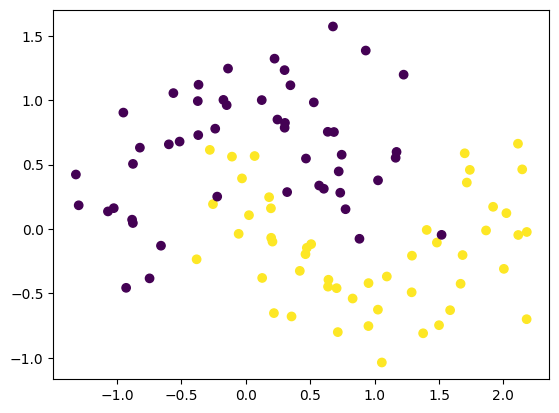

In [6]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [7]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [8]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# For Relu

In [9]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(2,activation='relu'))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 6         
                                                                 
 dense_1 (Dense)             (None, 2)                 6         
                                                                 
 dense_2 (Dense)             (None, 2)                 6         
                                                                 
 dense_3 (Dense)             (None, 2)                 6         
                                                                 
 dense_4 (Dense)             (None, 1)                 3         
                                                                 
Total params: 27
Trainable params: 27
Non-trainable params: 0
_________________________________________________________________


In [10]:
# Set parameters to 0
model.get_weights()

[array([[ 0.5877856 ,  1.1240741 ],
        [-0.45090503,  0.47332084]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.7837318 ,  0.77487564],
        [ 0.7469932 , -0.09613466]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.646657  ,  0.19116175],
        [-1.0368984 , -0.6755807 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.47554147,  0.62658656],
        [ 0.23734975, -0.99778056]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.1624919 ],
        [-0.76761514]], dtype=float32),
 array([0.], dtype=float32)]

In [11]:
model.get_weights()[1]

array([0., 0.], dtype=float32)

In [12]:
initial_weights = model.get_weights()

In [13]:
# initial_weights[0] = np.random.rand(model.get_weights()[0].shape[0],model.get_weights()[0].shape[1])*0.01
# initial_weights[1] = np.zeros(model.get_weights()[1].shape)
# initial_weights[2] = np.random.rand(model.get_weights()[2].shape[0],model.get_weights()[2].shape[1])*0.01
# initial_weights[3] = np.zeros(model.get_weights()[3].shape)
# initial_weights[4] = np.random.rand(model.get_weights()[4].shape[0],model.get_weights()[4].shape[1])*0.01
# initial_weights[5] = np.zeros(model.get_weights()[5].shape)
# initial_weights[6] = np.random.rand(model.get_weights()[6].shape[0],model.get_weights()[6].shape[1])*0.01
# initial_weights[7] = np.zeros(model.get_weights()[7].shape)
# initial_weights[8] = np.random.rand(model.get_weights()[8].shape[0],model.get_weights()[8].shape[1])*0.01
# initial_weights[9] = np.zeros(model.get_weights()[9].shape)

for i in range(0, len(initial_weights), 2):
    # Weight matrix
    # *initial_weights[i].shape -> will give you dimension of the weight matrix (x,y)
    initial_weights[i] = np.random.rand(*initial_weights[i].shape) * 0.01

    # Bias vector
    initial_weights[i + 1] = np.zeros(initial_weights[i + 1].shape)

model.set_weights(initial_weights)

In [14]:
model.set_weights(initial_weights)

In [15]:
model.get_weights()

[array([[0.00550913, 0.00076027],
        [0.00943531, 0.0055702 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.001222  , 0.0018878 ],
        [0.00057945, 0.00740498]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00650223, 0.00453249],
        [0.00514934, 0.00719064]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[1.0482260e-05, 3.9958959e-03],
        [8.0598490e-03, 6.2837745e-03]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00824247],
        [0.00604125]], dtype=float32),
 array([0.], dtype=float32)]

In [16]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 3s 105ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 21ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 20ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 21ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 23ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 22ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 21ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 8/100
3/3 [==

In [17]:
model.get_weights()

[array([[0.00550954, 0.00076065],
        [0.0094346 , 0.00556838]], dtype=float32),
 array([-3.5806360e-07, -1.8206879e-06], dtype=float32),
 array([[0.00122083, 0.00188619],
        [0.00057855, 0.00740373]], dtype=float32),
 array([-9.176637e-05, -1.266163e-04], dtype=float32),
 array([[0.00650215, 0.00453217],
        [0.005149  , 0.00718916]], dtype=float32),
 array([-0.00224382, -0.00432211], dtype=float32),
 array([[9.7188677e-06, 3.9953385e-03],
        [8.0589000e-03, 6.2830783e-03]], dtype=float32),
 array([-0.00597607, -0.00596543], dtype=float32),
 array([[0.00824155],
        [0.00604016]], dtype=float32),
 array([0.02499006], dtype=float32)]

9600/9600 [==============================] - 14s 1ms/step


<Axes: >

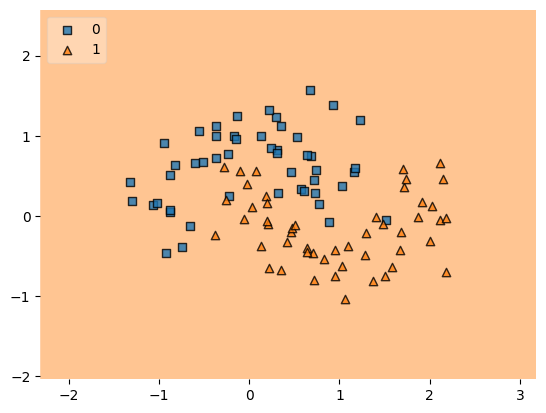

In [18]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

# tanh

In [30]:
model1 = Sequential()

model1.add(Dense(2,activation='tanh',input_dim=2))
model1.add(Dense(2,activation='tanh'))
model1.add(Dense(2,activation='tanh'))
model1.add(Dense(2,activation='tanh'))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_17 (Dense)            (None, 2)                 6         
                                                                 
 dense_18 (Dense)            (None, 2)                 6         
                                                                 
 dense_19 (Dense)            (None, 2)                 6         
                                                                 
 dense_20 (Dense)            (None, 2)                 6         
                                                                 
 dense_21 (Dense)            (None, 1)                 3         
                                                                 
Total params: 27
Trainable params: 27
Non-trainable params: 0
_________________________________________________________________


In [31]:
model1.get_weights()

[array([[0.6926496 , 0.1616931 ],
        [0.84536994, 0.6134552 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[1.1864308 , 0.26816702],
        [0.14689624, 1.1211838 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.15141964, -1.0825552 ],
        [-0.3101148 ,  0.9741565 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.85482633,  0.68629825],
        [-1.0408626 , -0.4588092 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.02886248],
        [ 1.272843  ]], dtype=float32),
 array([0.], dtype=float32)]

In [32]:
initial_weights1 = model1.get_weights()

In [33]:
# initial_weights1[0] = np.random.rand(model1.get_weights()[0].shape[0],model1.get_weights()[0].shape[1])*0.01
# initial_weights1[1] = np.zeros(model1.get_weights()[1].shape)
# initial_weights1[2] = np.random.rand(model1.get_weights()[2].shape[0],model1.get_weights()[2].shape[1])*0.01
# initial_weights1[3] = np.zeros(model1.get_weights()[3].shape)
# initial_weights1[4] = np.random.rand(model1.get_weights()[4].shape[0],model1.get_weights()[4].shape[1])*0.01
# initial_weights1[5] = np.zeros(model1.get_weights()[5].shape)
# initial_weights1[6] = np.random.rand(model1.get_weights()[6].shape[0],model1.get_weights()[6].shape[1])*0.01
# initial_weights1[7] = np.zeros(model1.get_weights()[7].shape)
# initial_weights1[8] = np.random.rand(model1.get_weights()[8].shape[0],model1.get_weights()[8].shape[1])*0.01
# initial_weights1[9] = np.zeros(model1.get_weights()[9].shape)

for i in range(0, len(initial_weights1), 2):
    # Weight matrix
    # *initial_weights1[i].shape -> will give you dimension of the weight matrix (x,y)
    initial_weights1[i] = np.random.rand(*initial_weights1[i].shape) * 0.01

    # Bias vector
    initial_weights1[i + 1] = np.zeros(initial_weights1[i + 1].shape)

model1.set_weights(initial_weights1)

In [34]:
model1.set_weights(initial_weights1)

In [35]:
model1.get_weights()

[array([[0.00270752, 0.00346575],
        [0.00780058, 0.00687461]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00096981, 0.00791469],
        [0.00712944, 0.00863809]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00546393, 0.0074142 ],
        [0.00199785, 0.00652829]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00644879, 0.0055336 ],
        [0.00788223, 0.00581556]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00633532],
        [0.00517972]], dtype=float32),
 array([0.], dtype=float32)]

In [36]:
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model1.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 1s 67ms/step - loss: 0.6932 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 17ms/step - loss: 0.6931 - accuracy: 0.4937 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 17ms/step - loss: 0.6932 - accuracy: 0.4051 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 16ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 16ms/step - loss: 0.6932 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 17ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 18ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 8/100
3/3 [===

In [37]:
model1.get_weights()

[array([[0.00270606, 0.00346268],
        [0.00780144, 0.00687643]], dtype=float32),
 array([2.0162507e-07, 4.0767321e-07], dtype=float32),
 array([[0.00097022, 0.00791496],
        [0.00712946, 0.0086381 ]], dtype=float32),
 array([2.9928246e-05, 2.0736554e-05], dtype=float32),
 array([[0.00546214, 0.00741206],
        [0.00199686, 0.00652707]], dtype=float32),
 array([0.00037553, 0.00036997], dtype=float32),
 array([[0.00320561, 0.00258012],
        [0.00446877, 0.00274393]], dtype=float32),
 array([ 3.8127735e-05, -8.5673280e-05], dtype=float32),
 array([[ 3.4923723e-05],
        [-3.5705962e-05]], dtype=float32),
 array([0.01241347], dtype=float32)]

9600/9600 [==============================] - 14s 1ms/step


<Axes: >

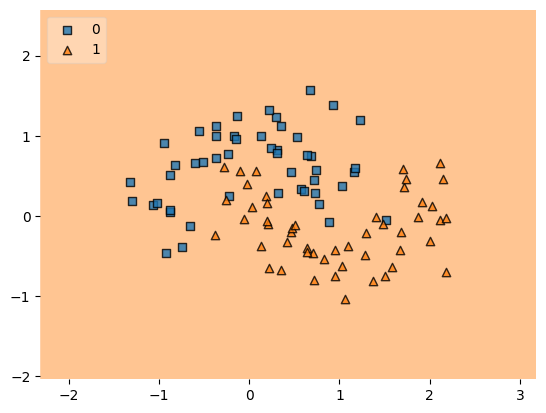

In [38]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model1, legend=2)

# Sigmoid

In [53]:
model2 = Sequential()

model2.add(Dense(2,activation='sigmoid',input_dim=2))
model2.add(Dense(2,activation='sigmoid'))
model2.add(Dense(2,activation='sigmoid'))
model2.add(Dense(2,activation='sigmoid'))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_32 (Dense)            (None, 2)                 6         
                                                                 
 dense_33 (Dense)            (None, 2)                 6         
                                                                 
 dense_34 (Dense)            (None, 2)                 6         
                                                                 
 dense_35 (Dense)            (None, 2)                 6         
                                                                 
 dense_36 (Dense)            (None, 1)                 3         
                                                                 
Total params: 27
Trainable params: 27
Non-trainable params: 0
_________________________________________________________________


In [47]:
model2.get_weights()

[array([[0.9958068 , 0.06279504],
        [0.4471321 , 0.00940943]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.25598145, -0.22218573],
        [ 0.18547261,  0.9370612 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.84368217, -0.19710743],
        [-0.3900591 , -1.2181643 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.36723006,  0.29086924],
        [ 0.3677659 , -0.9001833 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.32988334],
        [-0.4703086 ]], dtype=float32),
 array([0.], dtype=float32)]

In [48]:
initial_weights2 = model2.get_weights()

In [49]:
# initial_weights2[0] = np.random.rand(model2.get_weights()[0].shape[0],model2.get_weights()[0].shape[1])*0.01
# initial_weights2[1] = np.zeros(model2.get_weights()[1].shape)
# initial_weights2[2] = np.random.rand(model2.get_weights()[2].shape[0],model2.get_weights()[2].shape[1])*0.01
# initial_weights2[3] = np.zeros(model2.get_weights()[3].shape)
# initial_weights2[4] = np.random.rand(model2.get_weights()[4].shape[0],model2.get_weights()[4].shape[1])*0.01
# initial_weights2[5] = np.zeros(model2.get_weights()[5].shape)
# initial_weights2[6] = np.random.rand(model2.get_weights()[6].shape[0],model2.get_weights()[6].shape[1])*0.01
# initial_weights2[7] = np.zeros(model2.get_weights()[7].shape)
# initial_weights2[8] = np.random.rand(model2.get_weights()[8].shape[0],model2.get_weights()[8].shape[1])*0.01
# initial_weights2[9] = np.zeros(model2.get_weights()[9].shape)

for i in range(0, len(initial_weights2), 2):
    # Weight matrix
    # *initial_weights2[i].shape -> will give you dimension of the weight matrix (x,y)
    initial_weights2[i] = np.random.rand(*initial_weights2[i].shape) * 0.01

    # Bias vector
    initial_weights2[i + 1] = np.zeros(initial_weights2[i + 1].shape)

model2.set_weights(initial_weights2)

In [50]:
model2.set_weights(initial_weights2)

In [51]:
model2.get_weights()

[array([[0.00944279, 0.00701774],
        [0.00949032, 0.00688167]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00192778, 0.00660408],
        [0.00077935, 0.0062166 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00551807, 0.00682783],
        [0.0009129 , 0.0077694 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00566629, 0.0015664 ],
        [0.00248177, 0.0041364 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00671691],
        [0.00826783]], dtype=float32),
 array([0.], dtype=float32)]

In [52]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 0s 67ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/100
3/3 [==============================] - 0s 16ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 15ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/100
3/3 [==============================] - 0s 15ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 5/100
3/3 [==============================] - 0s 16ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 6/100
3/3 [==============================] - 0s 15ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 7/100
3/3 [==============================] - 0s 16ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 8/100
3/3 [===

In [54]:
model2.get_weights()

[array([[ 0.3927529 , -0.30133897],
        [ 0.8302871 ,  0.5898638 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.7501402 , -0.11787128],
        [-0.96610475, -0.8919722 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.7124307 , -0.934629  ],
        [-0.2109735 , -0.18985498]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.39879113,  0.11666203],
        [ 0.6825808 ,  0.03811502]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.00754392],
        [1.029662  ]], dtype=float32),
 array([0.], dtype=float32)]

9600/9600 [==============================] - 13s 1ms/step


<Axes: >

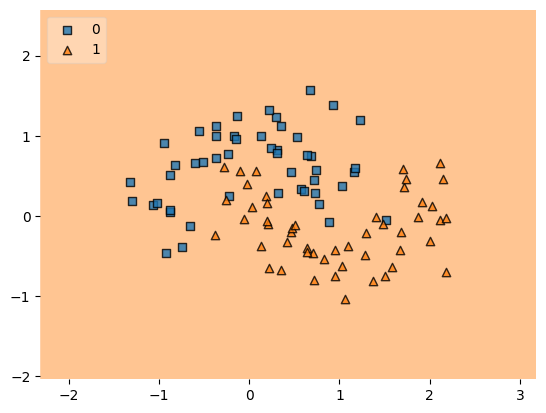

In [55]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model2, legend=2)